<a href="https://colab.research.google.com/github/dharshinikumaravel2004-byte/ecg-classification-resnet/blob/main/KLDivergence_Loss_(RESNET).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow
!pip install imbalanced-learn
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, BatchNormalization, GlobalAveragePooling1D, Add, Input, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/mit dataset/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/mit dataset/mitbih_test.csv"  # FIXED

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Mounted at /content/drive
Train shape: (87554, 188)
Test shape: (21892, 188)


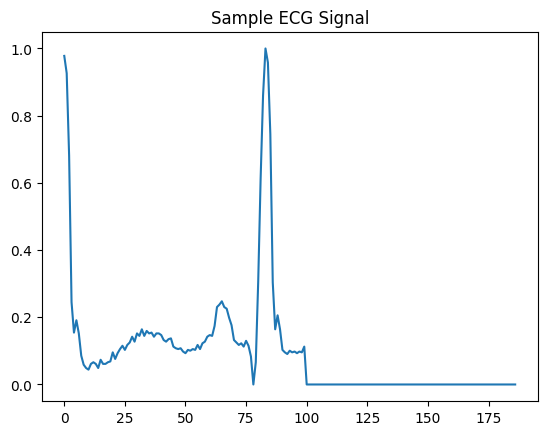

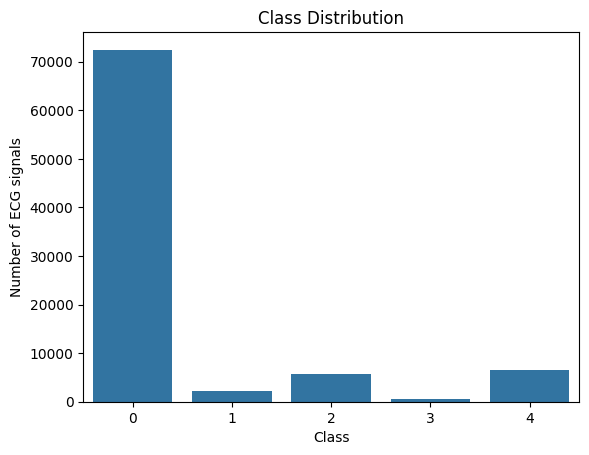

0
0


In [ ]:
plt.plot(train.iloc[0, :-1])
plt.title("Sample ECG Signal")
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0,1,2,3,4]

sns.barplot(x=classes, y=counts.values)
plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class Distribution")
plt.show()

print(train.isna().sum().sum())
print(test.isna().sum().sum())

In [ ]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_res).value_counts())

After SMOTE:
187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


In [ ]:
X_res = np.array(X_res).reshape(-1, 187, 1)
X_test = np.array(X_test).reshape(-1, 187, 1)

In [ ]:
# Convert to one-hot
y_res_cat = to_categorical(y_res, 5)
y_test_cat = to_categorical(y_test, 5)



In [ ]:
def resnet_ecg():

    inputs = Input(shape=(187,1))

    x = Conv1D(32, 3, activation='relu')(inputs)
    x = BatchNormalization()(x)

    x = resnet_block(x, 64)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x, 128)
    x = MaxPooling1D(2)(x)

    x = resnet_block(x, 256)

    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)

    outputs = Dense(5, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.KLDivergence(),
        metrics=['accuracy']
    )

    return model

In [ ]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=42
)

In [ ]:
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_res, y_res)):

    print(f"\nFold {fold+1}")

    X_tr, X_va = X_res[train_idx], X_res[val_idx]
    y_tr, y_va = y_res_cat[train_idx], y_res_cat[val_idx]

    model = resnet_ecg()

    model.fit(X_tr, y_tr, epochs=5, batch_size=64, verbose=1)

    loss, acc = model.evaluate(X_va, y_va, verbose=0)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    cv_accuracies.append(acc)

print("\nMean CV accuracy:", np.mean(cv_accuracies))


Fold 1
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 61s 11ms/step - accuracy: 0.9424 - loss: 0.1649
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9775 - loss: 0.0658
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9858 - loss: 0.0414
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - accuracy: 0.9899 - loss: 0.0298
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9922 - loss: 0.0232
Fold 1 Accuracy: 0.9391

Fold 2
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 52s 11ms/step - accuracy: 0.9442 - loss: 0.1603
Epoch 2/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9787 - loss: 0.0628
Epoch 3/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9861 - loss: 0.0413
Epoch 4/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9903 - loss: 0.0286
Epoch 5/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step - accuracy: 0.9924 - loss: 0.0226
Fold 2 Accuracy: 0.8341

Fold 3
Epoch 1/5
3775/3775 ━━━━━━━━━━━━━━━━━━━━ 50s 1

In [ ]:
model = resnet_ecg()

history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=10,
    batch_size=64
)

Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 66s 12ms/step - accuracy: 0.9500 - loss: 0.1432 - val_accuracy: 0.9351 - val_loss: 0.1880
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.9816 - loss: 0.0539 - val_accuracy: 0.7536 - val_loss: 0.7711
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 45s 10ms/step - accuracy: 0.9885 - loss: 0.0343 - val_accuracy: 0.6384 - val_loss: 1.8243
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.9919 - loss: 0.0242 - val_accuracy: 0.7974 - val_loss: 0.7007
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step - accuracy: 0.9938 - loss: 0.0189 - val_accuracy: 0.9942 - val_loss: 0.0182
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9949 - loss: 0.0151 - val_accuracy: 0.9518 - val_loss: 0.1387
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9958 - loss: 0.0125 - val_accuracy: 0.9931 - val_loss: 0.0198
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 82s 10ms/step - accuracy: 0.9965 -

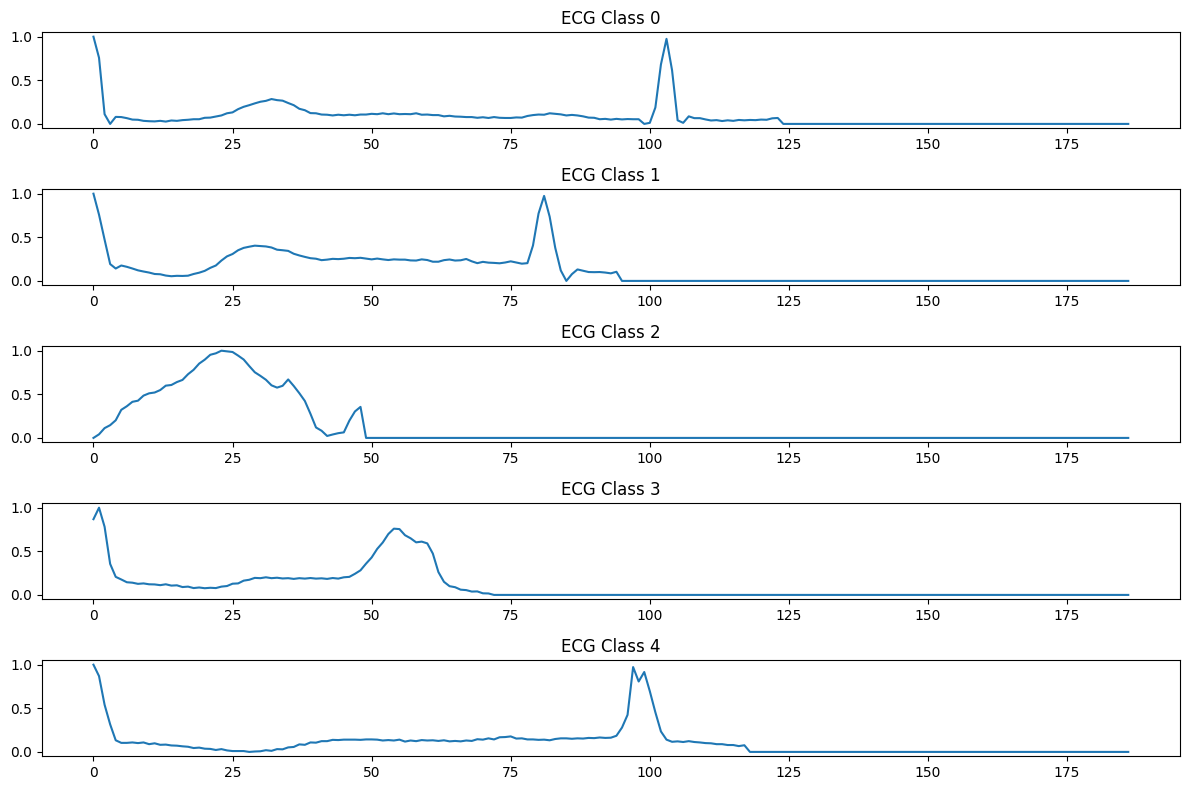

In [ ]:
plt.figure(figsize=(12,8))

for cls in range(5):
    idx = np.where(y_test == cls)[0][0]

    plt.subplot(5,1,cls+1)
    plt.plot(X_test[idx].reshape(187))
    plt.title(f"ECG Class {cls}")
    plt.tight_layout()

plt.show()

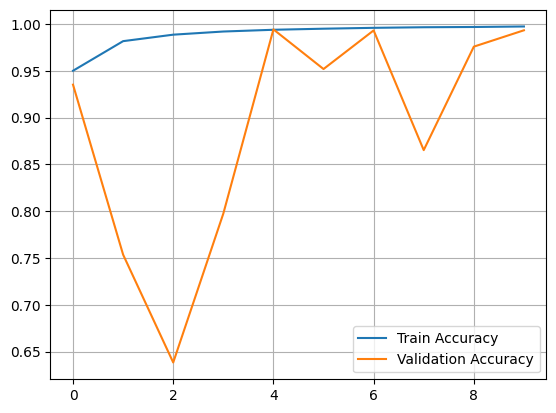

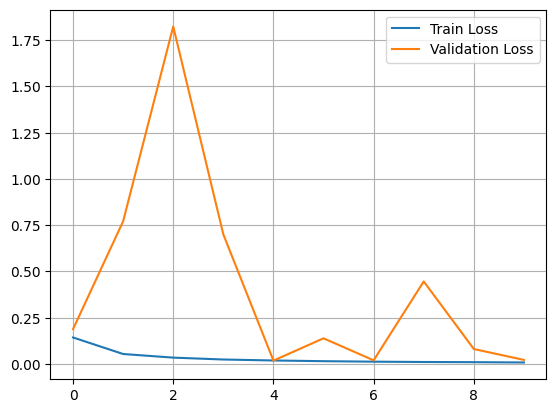

In [ ]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
y_val_pred_prob = model.predict(X_va)
y_val_pred = np.argmax(y_val_pred_prob, axis=1)

y_val_true = np.argmax(y_va, axis=1)

mcc_val = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc_val)

3775/3775 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step
Validation MCC: 0.993454484999826


In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(np.unique(y_pred))

685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
[0 1 2 3 4]


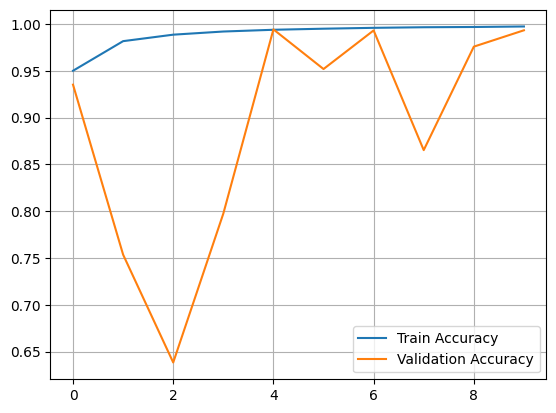

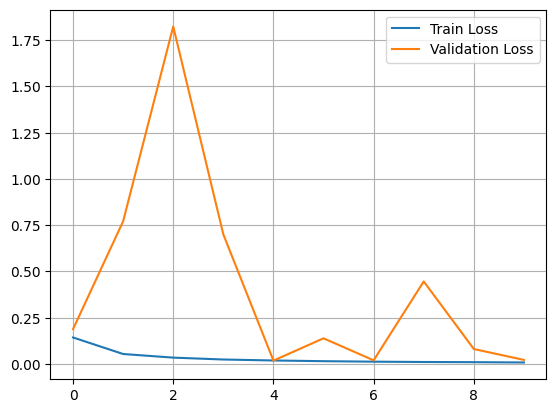

In [ ]:
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

y_test_pred = np.argmax(model.predict(X_test), axis=1)
y_test_true = np.argmax((y_test_cat + 1)//2, axis=1)

print(classification_report(y_test_true, y_test_pred))

Test Accuracy: 0.9801
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.77      0.80      0.78       556
           2       0.98      0.92      0.95      1448
           3       0.85      0.78      0.81       162
           4       0.98      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.91      0.90      0.90     21892
weighted avg       0.98      0.98      0.98     21892



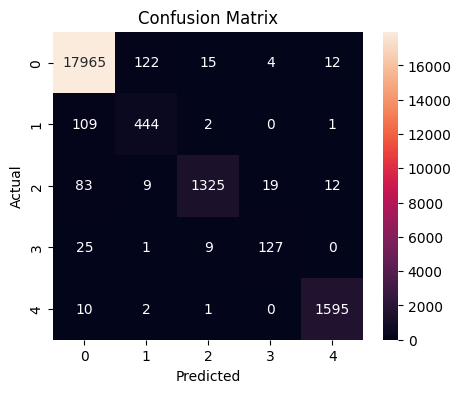

In [ ]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()